# YOLO11-seg (fine-tuned) — demo

Run the fine-tuned YOLO segmenter on one image.

## Setup — do this first

In a terminal, **from this folder**, create the virtualenv and install the
dependencies **before running any cell below**:

```bash
cd models/05_yolo_seg
python3 -m venv .venv && source .venv/bin/activate
pip install -r requirements.txt
```

Then select `.venv` as this notebook's kernel and run the cells top to bottom.

## 1. Load the model + fine-tuned weights

In [1]:
from ultralytics import YOLO

WEIGHTS = "runs/segment/train/weights/best.pt"    # produced by train_yolo_seg.py
model = YOLO(WEIGHTS)
print("loaded YOLO:", model.task, "| classes:", model.names)

loaded YOLO: segment | classes: {0: 'leaf'}


## 2. Predict on a sample image

In [2]:
SAMPLE = "../../data/cvppp/testing/images/A1/plant001_rgb.png"

res = model.predict(SAMPLE, conf=0.25, verbose=False)[0]
n = 0 if res.masks is None else len(res.masks)
print(f"found {n} leaves")

found 18 leaves


## 3. Show the output

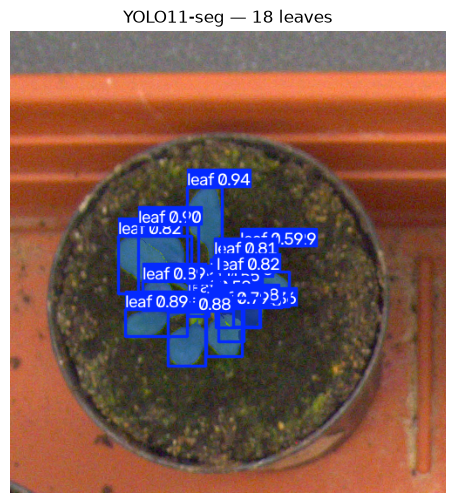

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(res.plot()[:, :, ::-1])      # .plot() draws masks+boxes in BGR; flip to RGB
plt.title(f"YOLO11-seg — {n} leaves"); plt.axis("off");